# 01 — MTSamples Dataset — Exploratory Data Analysis

> **Dataset:** [MTSamples](https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions) via HuggingFace `harishnair04/mtsamples`  
> **Purpose:** Understand dataset structure and build the SFT training corpus in Alpaca format for fine-tuning **LLaMA-3-8B**.

---

**Sections**

1. Setup & Data Loading  
2. Dataset Overview  
3. Medical Specialty Distribution & Class Imbalance  
4. Data Quality & Cleaning  
5. Length & Token Analysis  
6. SFT Dataset Construction (Alpaca Format)  
7. Summary & Recommendations

## 1. Setup & Data Loading

In [2]:
import warnings

warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import Dataset, DatasetDict
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

MTSAMPLES_PATH = "hf://datasets/harishnair04/mtsamples/mtsamples.csv"
SEED = 42
MIN_TRANSCRIPTION_CHARS = 100
MIN_DESCRIPTION_CHARS = 20
MIN_KEYWORDS_CHARS = 7
LLAMA3_MAX_TOKENS = 8_192
TOKEN_WORD_RATIO = 1.35

print("Setup complete")

Setup complete


In [3]:
df = pd.read_csv(MTSAMPLES_PATH)
df = df.rename(columns={"Unnamed: 0": "record_id"})
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Shape: 4,999 rows x 6 columns


,record_id,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


## 2. Dataset Overview

In [4]:
missing = df.isnull().sum()
overview = pd.DataFrame(
    {
        "dtype": df.dtypes,
        "non_null": df.notna().sum(),
        "missing_n": missing,
        "missing_%": (missing / len(df) * 100).round(2),
        "unique": df.nunique(),
    }
)
display(overview)

,dtype,non_null,missing_n,missing_%,unique
record_id,int64,4999,0,0.00,4999
description,object,4999,0,0.00,2348
medical_specialty,object,4999,0,0.00,40
sample_name,object,4999,0,0.00,2377
transcription,object,4966,33,0.66,2357
keywords,object,3931,1068,21.36,3849


## 3. Medical Specialty Distribution & Class Imbalance

The dataset covers **40 specialties**. Severe imbalance affects:
- Stratified train/val/test splitting strategy
- Evaluation reliability on rare specialties
- Whether oversampling or class-weighted loss is warranted during fine-tuning

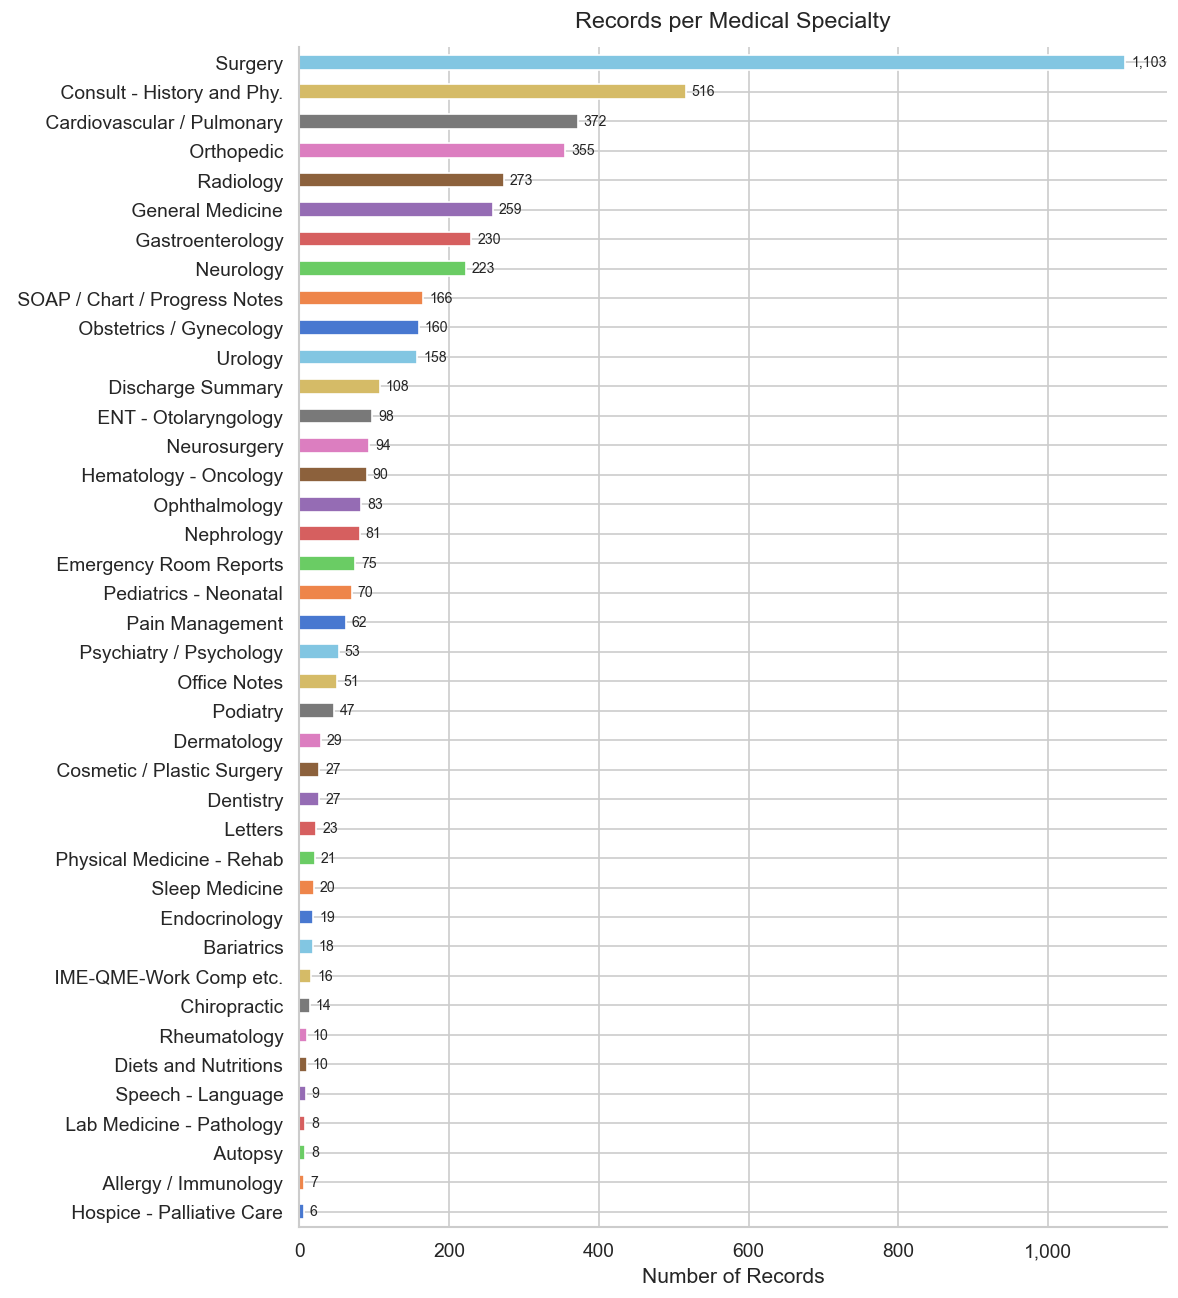

Most common  :  Surgery (1103 records)
Least common :  Hospice - Palliative Care (6 records)
Imbalance ratio: 184x

Specialties with < 20 records:


,count
medical_specialty,
Endocrinology,19
Bariatrics,18
IME-QME-Work Comp etc.,16
Chiropractic,14
Rheumatology,10
Diets and Nutritions,10
Speech - Language,9
Autopsy,8
Lab Medicine - Pathology,8


In [5]:
specialty_counts = df["medical_specialty"].value_counts()

fig, ax = plt.subplots(figsize=(10, 11))
colors = sns.color_palette("muted", len(specialty_counts))
specialty_counts.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_title("Records per Medical Specialty", fontsize=14, pad=12)
ax.set_xlabel("Number of Records")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width()):,}",
        (p.get_width() + 8, p.get_y() + p.get_height() / 2),
        va="center",
        fontsize=8.5,
    )
plt.tight_layout()
plt.show()

top, bottom = specialty_counts.index[0], specialty_counts.index[-1]
ratio = specialty_counts.iloc[0] / specialty_counts.iloc[-1]
print(f"Most common  : {top} ({specialty_counts.iloc[0]} records)")
print(f"Least common : {bottom} ({specialty_counts.iloc[-1]} records)")
print(f"Imbalance ratio: {ratio:.0f}x")
print("\nSpecialties with < 20 records:")
display(specialty_counts[specialty_counts < 20].to_frame("count"))

## 4. Data Quality & Cleaning

Two issues identified:

1. **Boilerplate disclaimer** embedded in ~253 `keywords` rows — stripped below.
2. **Very short or null transcriptions** — filtered at dataset construction time.

In [5]:
DISCLAIMER = (
    "NOTE,: Thesetranscribed medical transcription sample reports and examples are provided "
    "by various users andare for reference purpose only. MTHelpLine does not certify accuracy "
    "and quality of sample reports.These transcribed medical transcription sample reports may "
    "include some uncommon or unusual formats;this would be due to the preference of the dictating "
    "physician. All names and dates have beenchanged (or removed) to keep confidentiality. Any "
    "resemblance of any type of name or date orplace or anything "
    "else to real world is purely incidental."
)

mask = df["keywords"].notna() & df["keywords"].str.contains(DISCLAIMER, regex=False)
n_fixed = mask.sum()
df.loc[mask, "keywords"] = (
    df.loc[mask, "keywords"].str.replace(DISCLAIMER, "", regex=False).str.strip()
)

print(f"Disclaimer removed from : {n_fixed:,} rows")
print(f"Remaining NaN keywords  : {df['keywords'].isna().sum()}")
print(f"Remaining empty keywords: {(df['keywords'].fillna('').str.strip() == '').sum()}")

Disclaimer removed from : 253 rows
Remaining NaN keywords  : 1068
Remaining empty keywords: 1149


## 5. Length & Token Analysis

Word counts serve as a proxy for token counts (tokens ~ words x 1.35).

In [6]:
def word_count(s):
    return s.fillna("").astype(str).str.split().str.len()


df["desc_words"] = word_count(df["description"])
df["kw_words"] = word_count(df["keywords"])
df["trans_words"] = word_count(df["transcription"])
df["trans_tokens_approx"] = (df["trans_words"] * TOKEN_WORD_RATIO).astype(int)

stats = df[["desc_words", "kw_words", "trans_words", "trans_tokens_approx"]].describe().round(1)
stats.columns = [
    "Description (words)",
    "Keywords (words)",
    "Transcription (words)",
    "Transcription (tokens approx)",
]
display(stats)

,Description (words),Keywords (words),Transcription (words),Transcription (tokens approx)
count,4999.0,4999.0,4999.0,4999.0
mean,18.5,16.6,462.4,623.7
std,12.0,12.3,317.6,428.7
min,0.0,0.0,0.0,0.0
25%,9.0,8.0,239.0,322.0
50%,16.0,17.0,397.0,535.0
75%,25.5,24.0,614.0,828.0
max,76.0,79.0,3029.0,4089.0


Context window        : 8,192 tokens
Effective budget      : 8,042 tokens (after 150-token overhead)
Transcriptions fit    : 4,999 / 4,999 (100.0%)
Transcriptions too long: 0 (0.0%)


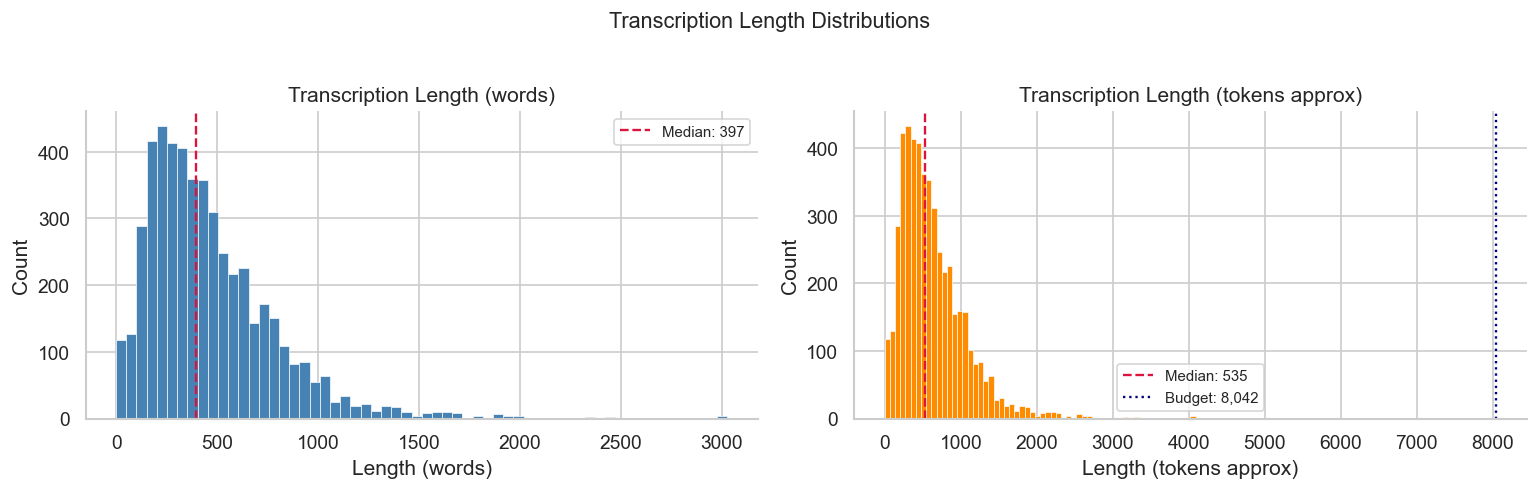

In [7]:
PROMPT_OVERHEAD = 150  # instruction + formatting + output description
budget = LLAMA3_MAX_TOKENS - PROMPT_OVERHEAD

fits = (df["trans_tokens_approx"] <= budget).sum()
print(f"Context window        : {LLAMA3_MAX_TOKENS:,} tokens")
print(f"Effective budget      : {budget:,} tokens (after {PROMPT_OVERHEAD}-token overhead)")
print(f"Transcriptions fit    : {fits:,} / {len(df):,} ({fits / len(df) * 100:.1f}%)")
print(f"Transcriptions too long: {len(df) - fits:,} ({(len(df) - fits) / len(df) * 100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, label, color in [
    (axes[0], "trans_words", "Length (words)", "steelblue"),
    (axes[1], "trans_tokens_approx", "Length (tokens approx)", "darkorange"),
]:
    med = df[col].median()
    ax.hist(df[col], bins=60, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(med, color="crimson", linestyle="--", linewidth=1.4, label=f"Median: {med:,.0f}")
    if col == "trans_tokens_approx":
        ax.axvline(budget, color="navy", linestyle=":", linewidth=1.4, label=f"Budget: {budget:,}")
    ax.set_title(f"Transcription {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
plt.suptitle("Transcription Length Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. SFT Dataset Construction (Alpaca Format)

Each record maps to **up to four tasks**, multiplying the usable signal from ~4,500 valid records:

| Task | Instruction | Input | Output |
|---|---|---|---|
| `summarization` | Summarise the transcription | transcription | description |
| `classification` | Identify the specialty | transcription | medical_specialty |
| `keyword_extraction` | Extract key clinical terms | transcription | keywords |
| `rag_augmented` | Clinical assessment with evidence | transcription + PubMed context | description |

---

**Format note:** The raw Alpaca string used here is a development placeholder.  
At training time with Unsloth + LLaMA-3, use `tokenizer.apply_chat_template()` with a `[system, user, assistant]` message list to correctly embed `SYSTEM_PROMPT` and generate proper BOS/EOS special tokens.  
Currently `SYSTEM_PROMPT` is defined but **not embedded** — fix this before training.

In [8]:
ALPACA_PROMPT = (
    "Below is a clinical instruction paired with relevant input. "
    "Write a response appropriate for a clinical AI assistant.\n\n"
    "### Instruction:\n{instruction}\n\n"
    "### Input:\n{input}\n\n"
    "### Response:\n{output}"
)

# Embed via tokenizer.apply_chat_template() at training time
SYSTEM_PROMPT = (
    "You are a clinical AI assistant trained to support evidence-based medicine. "
    "When provided with retrieved medical literature, integrate it into your reasoning."
)

LLAMA3_EOS = "<|eot_id|>"  # correct LLaMA-3 EOS token


def format_alpaca(examples: dict) -> dict:
    """Development placeholder. Replace with apply_chat_template() before training."""
    texts = [
        ALPACA_PROMPT.format(instruction=i, input=inp, output=o) + LLAMA3_EOS
        for i, inp, o in zip(examples["instruction"], examples["input"], examples["output"])
    ]
    return {"text": texts}

In [9]:
def _valid(text: str, min_chars: int) -> bool:
    t = str(text).strip()
    return bool(t) and t.lower() != "nan" and len(t) >= min_chars


def build_summarization_example(row):
    trans, desc = str(row.get("transcription", "")).strip(), str(row.get("description", "")).strip()
    if not (_valid(trans, MIN_TRANSCRIPTION_CHARS) and _valid(desc, MIN_DESCRIPTION_CHARS)):
        return None
    return {
        "instruction": "Summarize the following clinical transcription into a concise description.",
        "input": trans,
        "output": desc,
        "task_type": "summarization",
        "medical_specialty": str(row.get("medical_specialty", "")).strip(),
    }


def build_classification_example(row):
    trans = str(row.get("transcription", "")).strip()
    spec = str(row.get("medical_specialty", "")).strip()
    if not (_valid(trans, MIN_TRANSCRIPTION_CHARS) and spec):
        return None
    return {
        "instruction": "Identify the medical specialty of the following clinical note.",
        "input": trans,
        "output": spec,
        "task_type": "classification",
        "medical_specialty": spec,
    }


def build_keyword_extraction_example(row):
    trans = str(row.get("transcription", "")).strip()
    kw = str(row.get("keywords", "")).strip()
    if not (_valid(trans, MIN_TRANSCRIPTION_CHARS) and _valid(kw, MIN_KEYWORDS_CHARS)):
        return None
    return {
        "instruction": (
            "Extract the key medical terms, diagnoses, procedures, and "
            "clinical concepts from the following transcription."
        ),
        "input": trans,
        "output": kw,
        "task_type": "keyword_extraction",
        "medical_specialty": str(row.get("medical_specialty", "")).strip(),
    }


def build_rag_augmented_example(row, pubmed_context: str):
    """At training time, pubmed_context is pre-retrieved per specialty/keyword cluster.
    At inference time, it is replaced by live Qdrant retrieval.
    """
    trans = str(row.get("transcription", "")).strip()
    desc = str(row.get("description", "")).strip()
    if not (
        _valid(trans, MIN_TRANSCRIPTION_CHARS)
        and _valid(desc, MIN_DESCRIPTION_CHARS)
        and pubmed_context
    ):
        return None
    return {
        "instruction": (
            "You are a clinical assistant. Using the patient note and the retrieved "
            "medical evidence below, provide a clinically grounded summary and assessment."
        ),
        "input": f"PATIENT NOTE:\n{trans}\n\nRETRIEVED MEDICAL EVIDENCE:\n{pubmed_context}",
        "output": desc,
        "task_type": "rag_augmented",
        "medical_specialty": str(row.get("medical_specialty", "")).strip(),
    }

In [11]:
def build_dataset(df, pubmed_contexts=None, train_ratio=0.80, val_ratio=0.10, seed=SEED):
    """Constructs the SFT DatasetDict from cleaned MTSamples.

    pubmed_contexts : dict {specialty -> pubmed_text}, or None to skip rag_augmented task.
    test split (0.10) is held out for the 4-configuration ablative evaluation.
    """
    examples = []
    for _, row in df.iterrows():
        for builder in [
            build_summarization_example,
            build_classification_example,
            build_keyword_extraction_example,
        ]:
            ex = builder(row)
            if ex:
                examples.append(ex)
        if pubmed_contexts:
            ctx = pubmed_contexts.get(str(row.get("medical_specialty", "")).strip(), "")
            ex = build_rag_augmented_example(row, ctx)
            if ex:
                examples.append(ex)

    ds = Dataset.from_list(examples).shuffle(seed=seed)
    n, n_train, n_val = len(ds), int(len(ds) * train_ratio), int(len(ds) * val_ratio)
    return DatasetDict(
        {
            "train": ds.select(range(n_train)),
            "validation": ds.select(range(n_train, n_train + n_val)),
            "test": ds.select(range(n_train + n_val, n)),
        }
    )


splits = build_dataset(df)
total = sum(len(ds) for ds in splits.values())
print(f"{'':-<42}\n{'Split':<14} {'Examples':>10}\n{'':-<42}")
for name, ds in splits.items():
    print(f"{name:<14} {len(ds):>10,}  ({len(ds) / total * 100:.1f}%)")
print(f"{'':-<42}\n{'TOTAL':<14} {total:>10,}")

------------------------------------------
Split            Examples
------------------------------------------
train              10,868  (80.0%)
validation          1,358  (10.0%)
test                1,360  (10.0%)
------------------------------------------
TOTAL              13,586


,task_type,n,pct
0,classification,4921,36.2
1,summarization,4886,36.0
2,keyword_extraction,3779,27.8


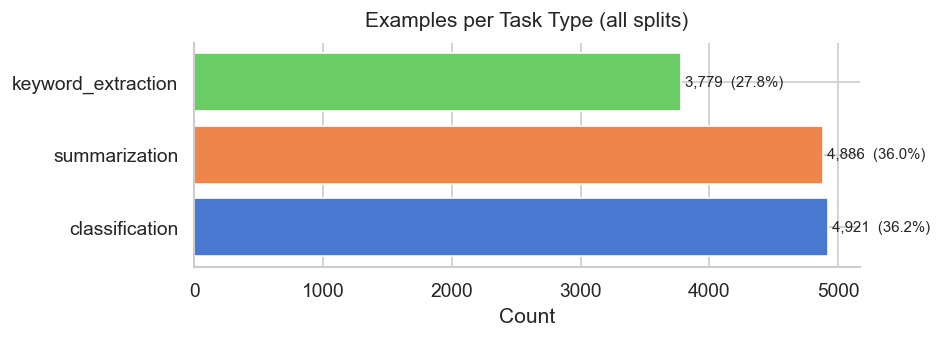

In [12]:
# Task distribution across all splits
all_rows = pd.DataFrame([ex for ds in splits.values() for ex in ds])
task_dist = all_rows["task_type"].value_counts().reset_index().rename(columns={"count": "n"})
task_dist["pct"] = (task_dist["n"] / task_dist["n"].sum() * 100).round(1)
display(task_dist)

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(task_dist["task_type"], task_dist["n"], color=sns.color_palette("muted", len(task_dist)))
ax.set_title("Examples per Task Type (all splits)", pad=10)
ax.set_xlabel("Count")
for i, (n, pct) in enumerate(zip(task_dist["n"], task_dist["pct"])):
    ax.annotate(f"{n:,}  ({pct}%)", (n + 30, i), va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# Sample rendered examples for each task type
train_df = splits["train"].to_pandas()
sep = chr(9473) * 72

for task in ["summarization", "classification", "keyword_extraction"]:
    row = train_df[train_df["task_type"] == task].sample(1, random_state=SEED).iloc[0]
    print(f"\n{sep}")
    print(f"  TASK: {task.upper()}   |   Specialty: {row['medical_specialty'].strip()}")
    print(sep)
    print(f"INSTRUCTION:\n  {row['instruction']}\n")
    print(f"INPUT (first 500 chars):\n  {row['input'][:500].replace(chr(10), ' ')}...\n")
    print(f"OUTPUT:\n  {row['output'][:300]}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TASK: SUMMARIZATION   |   Specialty: General Medicine
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSTRUCTION:
  Summarize the following clinical transcription into a concise description.

INPUT (first 500 chars):
  HISTORY OF PRESENT ILLNESS: , The patient is an 85-year-old male who was brought in by EMS with a complaint of a decreased level of consciousness.  The patient apparently lives with his wife and was found to have a decreased status since the last one day.  The patient actually was seen in the emergency room the night before for injuries of the face and for possible elderly abuse.  When the Adult Protective Services actually went to the patient's house, he was found to be having decreased conscio...

OUTPUT:
  The patient brought in by EMS with a complaint of a decreased level of consciousness.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TA